In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [3]:
data = pd.read_csv("../data/netflix.csv")

In [4]:
data = data.ffill()

In [8]:
encoder = LabelEncoder()

data['type'] = encoder.fit_transform(data['type'])
data['rating'] = encoder.fit_transform(data['rating'])

In [10]:
# Extract numeric duration
data['duration_num'] = data['duration'].str.extract(r'(\d+)').astype(float)

In [11]:
features = data[['release_year', 'duration_num', 'type']]

In [12]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

In [13]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

print("Explained Variance:", pca.explained_variance_ratio_)

Explained Variance: [0.65765976 0.30492123]


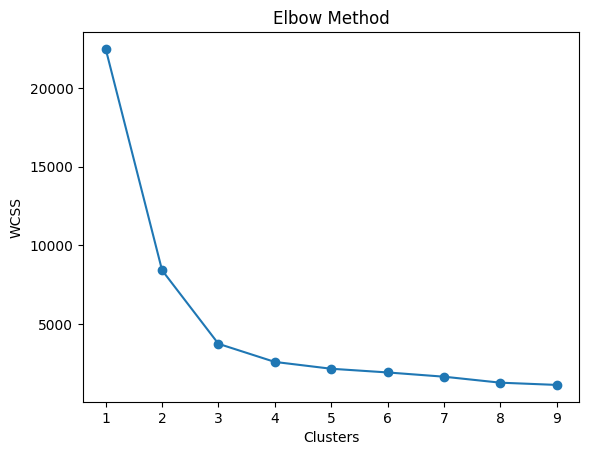

In [16]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [17]:
model = KMeans(n_clusters=3, random_state=42)
clusters = model.fit_predict(pca_data)

data['cluster'] = clusters

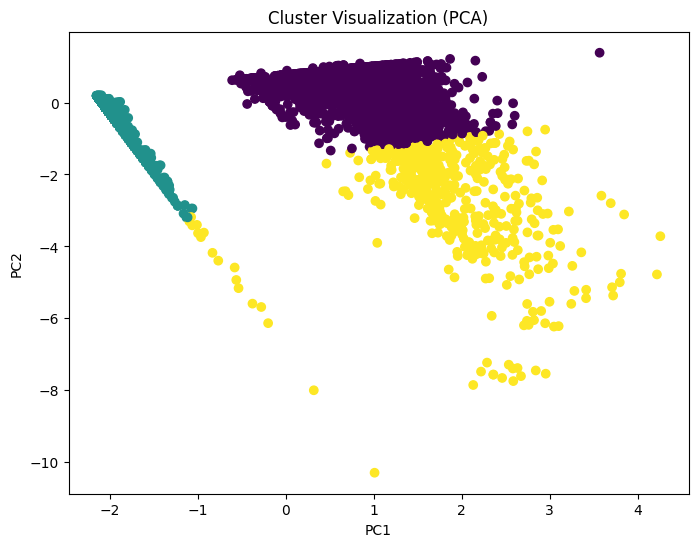

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters)
plt.title("Cluster Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [19]:
score = silhouette_score(pca_data, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.7470654435150479


In [ ]:
data.groupby('cluster')[['release_year','duration_num']].mean()